# Chapter 10: Support Vector Machines

MATH 4230 Capstone Project  |  Christian Rodriguez  |  Spring 2026

Dataset: Student Lifestyle, Mental Health and Burnout Insight

<div style="text-align:center; font-style:italic; font-size:1.05em; margin: 16px 0;">
Support vector machines test whether a flexible nonlinear boundary improves high-risk classification enough to justify giving up the interpretability of logistic regression.
</div>

## Setup

In [17]:
# Standard library
import os
import warnings

# Core data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Metrics and model selection
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    train_test_split,
)

# Models
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

# Consistent plot style across all chapters
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

FIGURES_DIR = '../figures/ch10/'
RESULTS_DIR = '../results/ch10/'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete.')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'Figures -> {FIGURES_DIR}')
print(f'Results -> {RESULTS_DIR}')

Setup complete.
RANDOM_STATE = 230
Figures -> ../figures/ch10/
Results -> ../results/ch10/


## §1. The Question

Does allowing for a nonlinear boundary between high-risk and low-risk students improve classification accuracy over the logistic regression model from Chapter 5, and is that improvement large enough to justify replacing an interpretable model with one that cannot explain individual predictions?

## §2. Method in Brief

A support vector machine separates two classes by finding a hyperplane with the widest possible margin between them. The points closest to the boundary are called support vectors because they determine where the boundary is placed.

The **C parameter** controls how strongly the model penalizes classification mistakes. A small C allows a wider margin with more mistakes, while a large C tries harder to classify the training points correctly, which can increase overfitting.

The **kernel trick** lets an SVM create nonlinear boundaries without explicitly building new nonlinear features. In this chapter, the linear SVM tests a straight boundary, while the radial basis function kernel tests a curved boundary controlled by **gamma**, which determines how local or flexible the curve becomes.

## §3. Why This Method?

Logistic regression from Chapter 5 assumes that the separation between high-risk and low-risk students is linear on the predictor scale. A support vector machine is useful here because it can test whether a sharper boundary exists when the model is allowed to focus on the most difficult boundary cases. The linear SVM checks whether a margin-based linear classifier improves on logistic regression, while the radial basis function SVM checks whether a nonlinear boundary improves classification. The trade-off is interpretability: logistic regression gives coefficients and odds ratios, but an SVM does not explain individual predictions in the same direct way. Therefore, the SVM needs a meaningful performance gain before it would be worth replacing the simpler model.

## §4. Data Setup

This chapter uses the Chapter 2 preprocessed arrays: `X_train`, `X_test`, `y_train_cls`, `y_test_cls`, and `feature_names`. The features were already standardized in Chapter 2, which is important because support vector machines depend on distances and margins.

Support vector machines can be computationally expensive on large datasets, especially with a nonlinear kernel. For that reason, the models are fit and tuned on a stratified 15,000-row subsample of the 140,000-row training set. Stratification preserves the class balance in the subsample. Final evaluation is still performed on the full 40,000-row test set, so the reported test metrics reflect performance on the same held-out test set used in the other chapters.

In [18]:
# Load Chapter 2 arrays
X_train = np.load('../results/X_train.npy')
X_test = np.load('../results/X_test.npy')
y_train_cls = np.load('../results/y_train_cls.npy')
y_test_cls = np.load('../results/y_test_cls.npy')
feature_names = joblib.load('../results/feature_names.pkl')

# Robust binary conversion.
# If the classification arrays are already 0 or 1, keep them.
# If they contain three classes, treat the highest label as High risk and combine the rest.
def make_binary_risk(y):
    labels = np.unique(y)
    if set(labels).issubset({0, 1}):
        return y.astype(int), 1
    high_label = 2 if 2 in labels else labels.max()
    return (y == high_label).astype(int), high_label

y_train_bin, high_label_train = make_binary_risk(y_train_cls)
y_test_bin, high_label_test = make_binary_risk(y_test_cls)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'y_train_bin shape: {y_train_bin.shape}')
print(f'y_test_bin shape : {y_test_bin.shape}')
print(f'High-risk source label in training data: {high_label_train}')
print()
print('Training class distribution after binary conversion:')
for label, count in zip(*np.unique(y_train_bin, return_counts=True)):
    print(f'  {label}: {count:,} ({count / len(y_train_bin) * 100:.2f}%)')
print()
print('Test class distribution after binary conversion:')
for label, count in zip(*np.unique(y_test_bin, return_counts=True)):
    print(f'  {label}: {count:,} ({count / len(y_test_bin) * 100:.2f}%)')

X_train shape: (140000, 19)
X_test shape : (40000, 19)
y_train_bin shape: (140000,)
y_test_bin shape : (40000,)
High-risk source label in training data: 2

Training class distribution after binary conversion:
  0: 137,889 (98.49%)
  1: 2,111 (1.51%)

Test class distribution after binary conversion:
  0: 39,397 (98.49%)
  1: 603 (1.51%)


In [19]:
# Create a stratified 15,000-row training subsample for SVM fitting
sample_indices = np.arange(X_train.shape[0])
sub_idx, _ = train_test_split(
    sample_indices,
    train_size=15000,
    stratify=y_train_bin,
    random_state=RANDOM_STATE,
)

X_svm = X_train[sub_idx]
y_svm = y_train_bin[sub_idx]

print(f'SVM fitting subsample shape: {X_svm.shape}')
print('Subsample class distribution:')
for label, count in zip(*np.unique(y_svm, return_counts=True)):
    print(f'  {label}: {count:,} ({count / len(y_svm) * 100:.2f}%)')

SVM fitting subsample shape: (15000, 19)
Subsample class distribution:
  0: 14,774 (98.49%)
  1: 226 (1.51%)


## §5. Analysis

### Linear SVM

The linear SVM tests whether a margin-based straight boundary improves on logistic regression. The tuning parameter is C, which controls how much the model penalizes training errors.

In [20]:
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

linear_grid = GridSearchCV(
    estimator=LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    scoring='roc_auc',
    cv=skf5,
    n_jobs=-1,
    return_train_score=True,
)
linear_grid.fit(X_svm, y_svm)

best_c_linear = linear_grid.best_params_['C']
print(f'Best Linear SVM C: {best_c_linear}')
print(f'Best 5-fold CV AUC: {linear_grid.best_score_:.4f}')

linear_cv_results = pd.DataFrame(linear_grid.cv_results_)[
    ['param_C', 'mean_test_score', 'std_test_score', 'mean_train_score']
].sort_values('param_C')
linear_cv_results

Best Linear SVM C: 0.01
Best 5-fold CV AUC: 0.9816


,param_C,mean_test_score,std_test_score,mean_train_score
0,0.01,0.981576,0.005705,0.983107
1,0.10,0.981501,0.005270,0.983211
2,1.00,0.981467,0.005246,0.983213
3,10.00,0.981473,0.005224,0.983212


In [21]:
linear_svm = LinearSVC(C=best_c_linear, max_iter=2000, random_state=RANDOM_STATE)
linear_svm.fit(X_svm, y_svm)

linear_pred = linear_svm.predict(X_test)
linear_score = linear_svm.decision_function(X_test)

linear_accuracy = accuracy_score(y_test_bin, linear_pred)
linear_auc = roc_auc_score(y_test_bin, linear_score)
linear_report = classification_report(
    y_test_bin,
    linear_pred,
    target_names=['Not High', 'High'],
    output_dict=True,
    zero_division=0,
)
linear_high_precision = linear_report['High']['precision']
linear_high_recall = linear_report['High']['recall']
linear_high_f1 = linear_report['High']['f1-score']

print('Linear SVM test results:')
print(f'Accuracy       : {linear_accuracy:.4f}')
print(f'High Precision : {linear_high_precision:.4f}')
print(f'High Recall    : {linear_high_recall:.4f}')
print(f'High F1        : {linear_high_f1:.4f}')
print(f'AUC-ROC        : {linear_auc:.4f}')
print()
print(classification_report(y_test_bin, linear_pred, target_names=['Not High', 'High'], zero_division=0))

Linear SVM test results:
Accuracy       : 0.9853
High Precision : 0.8696
High Recall    : 0.0332
High F1        : 0.0639
AUC-ROC        : 0.9818

              precision    recall  f1-score   support

    Not High       0.99      1.00      0.99     39397
        High       0.87      0.03      0.06       603

    accuracy                           0.99     40000
   macro avg       0.93      0.52      0.53     40000
weighted avg       0.98      0.99      0.98     40000



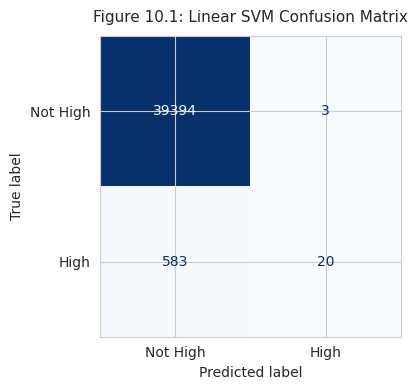

Saved: ../figures/ch10/linear_svm_confusion.png


In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_bin,
    linear_pred,
    display_labels=['Not High', 'High'],
    cmap='Blues',
    colorbar=False,
    ax=ax,
)
ax.set_title('Figure 10.1: Linear SVM Confusion Matrix', fontsize=11, pad=10)
plt.tight_layout()
fig_path_101 = os.path.join(FIGURES_DIR, 'linear_svm_confusion.png')
plt.savefig(fig_path_101, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_101}')

### RBF Kernel SVM

The radial basis function kernel SVM tests whether a nonlinear boundary improves classification. The C parameter controls the penalty for mistakes, while gamma controls how local and flexible the nonlinear boundary becomes.

In [23]:
rbf_grid = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=RANDOM_STATE, cache_size=1000),
    param_grid={
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.01],
    },
    scoring='roc_auc',
    cv=skf5,
    n_jobs=-1,
    return_train_score=True,
)
rbf_grid.fit(X_svm, y_svm)

best_c_rbf = rbf_grid.best_params_['C']
best_gamma_rbf = rbf_grid.best_params_['gamma']
print(f'Best RBF SVM C: {best_c_rbf}')
print(f'Best RBF SVM gamma: {best_gamma_rbf}')
print(f'Best 5-fold CV AUC: {rbf_grid.best_score_:.4f}')

rbf_cv_results = pd.DataFrame(rbf_grid.cv_results_)[
    ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'mean_train_score']
].sort_values(['param_C', 'param_gamma'])
rbf_cv_results

Best RBF SVM C: 0.1
Best RBF SVM gamma: 0.01
Best 5-fold CV AUC: 0.9773


,param_C,param_gamma,mean_test_score,std_test_score,mean_train_score
2,0.1,0.01,0.977304,0.007670,0.980241
1,0.1,auto,0.877293,0.030474,0.953405
0,0.1,scale,0.877266,0.030313,0.953374
5,1.0,0.01,0.977263,0.007758,0.980134
4,1.0,auto,0.879216,0.030856,0.962173
3,1.0,scale,0.879228,0.030805,0.962196
8,10.0,0.01,0.966532,0.010377,0.979757
7,10.0,auto,0.913244,0.015104,0.997143
6,10.0,scale,0.913250,0.015090,0.997146


In [24]:
rbf_svm = SVC(
    kernel='rbf',
    C=best_c_rbf,
    gamma=best_gamma_rbf,
    random_state=RANDOM_STATE,
    cache_size=1000,
)
rbf_svm.fit(X_svm, y_svm)

rbf_pred = rbf_svm.predict(X_test)
rbf_score = rbf_svm.decision_function(X_test)

rbf_accuracy = accuracy_score(y_test_bin, rbf_pred)
rbf_auc = roc_auc_score(y_test_bin, rbf_score)
rbf_report = classification_report(
    y_test_bin,
    rbf_pred,
    target_names=['Not High', 'High'],
    output_dict=True,
    zero_division=0,
)
rbf_high_precision = rbf_report['High']['precision']
rbf_high_recall = rbf_report['High']['recall']
rbf_high_f1 = rbf_report['High']['f1-score']

print('RBF SVM test results:')
print(f'Accuracy       : {rbf_accuracy:.4f}')
print(f'High Precision : {rbf_high_precision:.4f}')
print(f'High Recall    : {rbf_high_recall:.4f}')
print(f'High F1        : {rbf_high_f1:.4f}')
print(f'AUC-ROC        : {rbf_auc:.4f}')
print()
print(classification_report(y_test_bin, rbf_pred, target_names=['Not High', 'High'], zero_division=0))

RBF SVM test results:
Accuracy       : 0.9849
High Precision : 0.0000
High Recall    : 0.0000
High F1        : 0.0000
AUC-ROC        : 0.9748

              precision    recall  f1-score   support

    Not High       0.98      1.00      0.99     39397
        High       0.00      0.00      0.00       603

    accuracy                           0.98     40000
   macro avg       0.49      0.50      0.50     40000
weighted avg       0.97      0.98      0.98     40000



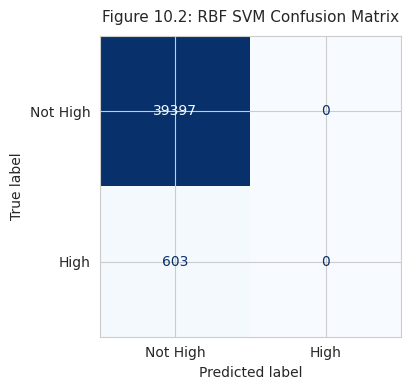

Saved: ../figures/ch10/rbf_svm_confusion.png


In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_bin,
    rbf_pred,
    display_labels=['Not High', 'High'],
    cmap='Blues',
    colorbar=False,
    ax=ax,
)
ax.set_title('Figure 10.2: RBF SVM Confusion Matrix', fontsize=11, pad=10)
plt.tight_layout()
fig_path_102 = os.path.join(FIGURES_DIR, 'rbf_svm_confusion.png')
plt.savefig(fig_path_102, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_102}')

## §6. Diagnostics and Tuning

The main tuning choices are the C value for the linear SVM, and both C and gamma for the RBF SVM. Both models are tuned using 5-fold stratified cross-validation on the 15,000-row training subsample. Stratification is used because the High-risk class is rare, so each fold needs to preserve the same class balance as the full training set.

In [26]:
# Logistic regression baseline from Chapter 5 for ROC comparison
# It is fit on the full training set because Chapter 5 used the full training data.
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train_bin)
log_pred = log_reg.predict(X_test)
log_score = log_reg.predict_proba(X_test)[:, 1]

log_accuracy = accuracy_score(y_test_bin, log_pred)
log_auc = roc_auc_score(y_test_bin, log_score)
log_report = classification_report(
    y_test_bin,
    log_pred,
    target_names=['Not High', 'High'],
    output_dict=True,
    zero_division=0,
)
log_high_f1 = log_report['High']['f1-score']

print('Logistic regression baseline:')
print(f'Accuracy: {log_accuracy:.4f}')
print(f'High F1 : {log_high_f1:.4f}')
print(f'AUC-ROC : {log_auc:.4f}')

Logistic regression baseline:
Accuracy: 0.9873
High F1 : 0.4258
AUC-ROC : 0.9827


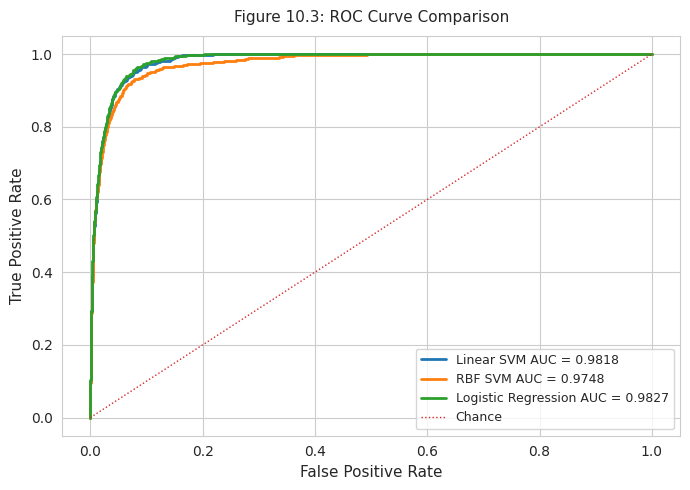

Saved: ../figures/ch10/roc_comparison.png


In [27]:
# Figure 10.3: ROC comparison
fpr_linear, tpr_linear, _ = roc_curve(y_test_bin, linear_score)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test_bin, rbf_score)
fpr_log, tpr_log, _ = roc_curve(y_test_bin, log_score)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_linear, tpr_linear, linewidth=2, label=f'Linear SVM AUC = {linear_auc:.4f}')
ax.plot(fpr_rbf, tpr_rbf, linewidth=2, label=f'RBF SVM AUC = {rbf_auc:.4f}')
ax.plot(fpr_log, tpr_log, linewidth=2, label=f'Logistic Regression AUC = {log_auc:.4f}')
ax.plot([0, 1], [0, 1], linestyle=':', linewidth=1, label='Chance')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Figure 10.3: ROC Curve Comparison', fontsize=11, pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
fig_path_103 = os.path.join(FIGURES_DIR, 'roc_comparison.png')
plt.savefig(fig_path_103, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_103}')

In [28]:
# Save tuning results for transparency
linear_cv_path = os.path.join(RESULTS_DIR, 'linear_svm_cv_results.csv')
rbf_cv_path = os.path.join(RESULTS_DIR, 'rbf_svm_cv_results.csv')
linear_cv_results.to_csv(linear_cv_path, index=False)
rbf_cv_results.to_csv(rbf_cv_path, index=False)

print('Linear SVM CV results:')
display(linear_cv_results)
print()
print('RBF SVM CV results:')
display(rbf_cv_results)
print()
print(f'Saved: {linear_cv_path}')
print(f'Saved: {rbf_cv_path}')

Linear SVM CV results:


,param_C,mean_test_score,std_test_score,mean_train_score
0,0.01,0.981576,0.005705,0.983107
1,0.10,0.981501,0.005270,0.983211
2,1.00,0.981467,0.005246,0.983213
3,10.00,0.981473,0.005224,0.983212



RBF SVM CV results:


,param_C,param_gamma,mean_test_score,std_test_score,mean_train_score
2,0.1,0.01,0.977304,0.007670,0.980241
1,0.1,auto,0.877293,0.030474,0.953405
0,0.1,scale,0.877266,0.030313,0.953374
5,1.0,0.01,0.977263,0.007758,0.980134
4,1.0,auto,0.879216,0.030856,0.962173
3,1.0,scale,0.879228,0.030805,0.962196
8,10.0,0.01,0.966532,0.010377,0.979757
7,10.0,auto,0.913244,0.015104,0.997143
6,10.0,scale,0.913250,0.015090,0.997146



Saved: ../results/ch10/linear_svm_cv_results.csv
Saved: ../results/ch10/rbf_svm_cv_results.csv


## §6b. Lab-Style SVM Boundary Visualization

The SVM lab notebook uses two-dimensional plots to show margins, support vectors, and nonlinear RBF boundaries. The full capstone model uses 19 standardized features, so a true full-dimensional SVM boundary cannot be drawn on a flat page. To keep the same visual idea from the lab, this section builds two-feature visual SVMs using `stress_level` and `anxiety_score`, two of the strongest risk-related predictors from earlier chapters.

Only Figure 10.4 belongs in the main Chapter 10 section. The additional lab-style plots are generated later under Appendix C because they support the explanation but are not part of the main chapter numbering.

### Main-report note

Figure 10.4 is the only lab-style SVM plot intended for the main Chapter 10 section. It compares linear and RBF boundaries for Low vs High, Medium vs High, and Low vs Medium using the same two features. The official Chapter 10 model comparison still comes from the full 19-feature Linear SVM, RBF SVM, and logistic regression results.

In [29]:
# Lab-style SVM plotting helpers
# These functions adapt the SVM_Lab_Python notebook decision-boundary plots
# to this capstone dataset.

def plot_svm_decision_boundary(clf, X_2d, y, title="", ax=None, class_labels=("Class 0", "Class 1")):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x_min, x_max = X_2d[:, 0].min() - 0.75, X_2d[:, 0].max() + 0.75
    y_min, y_max = X_2d[:, 1].min() - 0.75, X_2d[:, 1].max() + 0.75

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 220),
        np.linspace(y_min, y_max, 220)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=20, alpha=0.18)
    ax.contour(
        xx,
        yy,
        Z,
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        linewidths=[1, 2, 1]
    )

    ax.scatter(
        X_2d[y == 0, 0],
        X_2d[y == 0, 1],
        s=22,
        alpha=0.45,
        edgecolors="none",
        label=class_labels[0]
    )

    ax.scatter(
        X_2d[y == 1, 0],
        X_2d[y == 1, 1],
        s=28,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.3,
        label=class_labels[1]
    )

    if hasattr(clf, "support_vectors_"):
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=80,
            facecolors="none",
            edgecolors="black",
            linewidths=1.0,
            label="Support vectors"
        )

    ax.set_xlabel("stress_level")
    ax.set_ylabel("anxiety_score")
    ax.set_title(title, fontsize=10, pad=8)
    ax.legend(fontsize=7, loc="best")
    return ax


def make_pairwise_data(X, y_multiclass, class_a, class_b, feature_x="stress_level", feature_y="anxiety_score", sample_n=2500):
    # Pull two feature columns
    ix = feature_names.index(feature_x)
    iy = feature_names.index(feature_y)

    mask = np.isin(y_multiclass, [class_a, class_b])
    X_pair = X[mask][:, [ix, iy]]
    y_pair_raw = y_multiclass[mask]

    # Convert selected pair to 0 and 1
    y_pair = (y_pair_raw == class_b).astype(int)

    # Stratified sample for plotting speed and readability
    if X_pair.shape[0] > sample_n:
        idx = np.arange(X_pair.shape[0])
        sample_idx, _ = train_test_split(
            idx,
            train_size=sample_n,
            stratify=y_pair,
            random_state=RANDOM_STATE
        )
        X_pair = X_pair[sample_idx]
        y_pair = y_pair[sample_idx]

    return X_pair, y_pair

In [30]:
# Prepare class labels and pairwise combinations.
# If the saved target has three classes, use Low, Medium, and High.
# If it is already binary, the Low vs High pair still works.

unique_classes = sorted(np.unique(y_train_cls).tolist())

if len(unique_classes) >= 3:
    class_name_map = {
        unique_classes[0]: "Low",
        unique_classes[1]: "Medium",
        unique_classes[2]: "High"
    }
    pairwise_comparisons = [
        (unique_classes[0], unique_classes[2], "Low vs High"),
        (unique_classes[1], unique_classes[2], "Medium vs High"),
        (unique_classes[0], unique_classes[1], "Low vs Medium")
    ]
else:
    class_name_map = {
        unique_classes[0]: "Low",
        unique_classes[1]: "High"
    }
    pairwise_comparisons = [
        (unique_classes[0], unique_classes[1], "Low vs High")
    ]

print("Pairwise comparisons for SVM visualizations:")
for a, b, label in pairwise_comparisons:
    print(f"{label}: {class_name_map[a]} = 0, {class_name_map[b]} = 1")

Pairwise comparisons for SVM visualizations:
Low vs High: Low = 0, High = 1
Medium vs High: Medium = 0, High = 1
Low vs Medium: Low = 0, Medium = 1


In [31]:
# Prepare pairwise data for the lab-style SVM visualizations
# These data are reused by the main visual figure and the appendix figures.

pairwise_visual_data = {}

for class_a, class_b, pair_label in pairwise_comparisons:
    X_pair, y_pair = make_pairwise_data(
        X_train,
        y_train_cls,
        class_a,
        class_b,
        feature_x="stress_level",
        feature_y="anxiety_score",
        sample_n=2500
    )

    pairwise_visual_data[pair_label] = (X_pair, y_pair, class_a, class_b)

print("Pairwise visual datasets prepared:")
for pair_label, (X_pair, y_pair, class_a, class_b) in pairwise_visual_data.items():
    print(f"{pair_label}: {X_pair.shape[0]:,} plotted rows")

Pairwise visual datasets prepared:
Low vs High: 2,500 plotted rows
Medium vs High: 2,500 plotted rows
Low vs Medium: 2,500 plotted rows


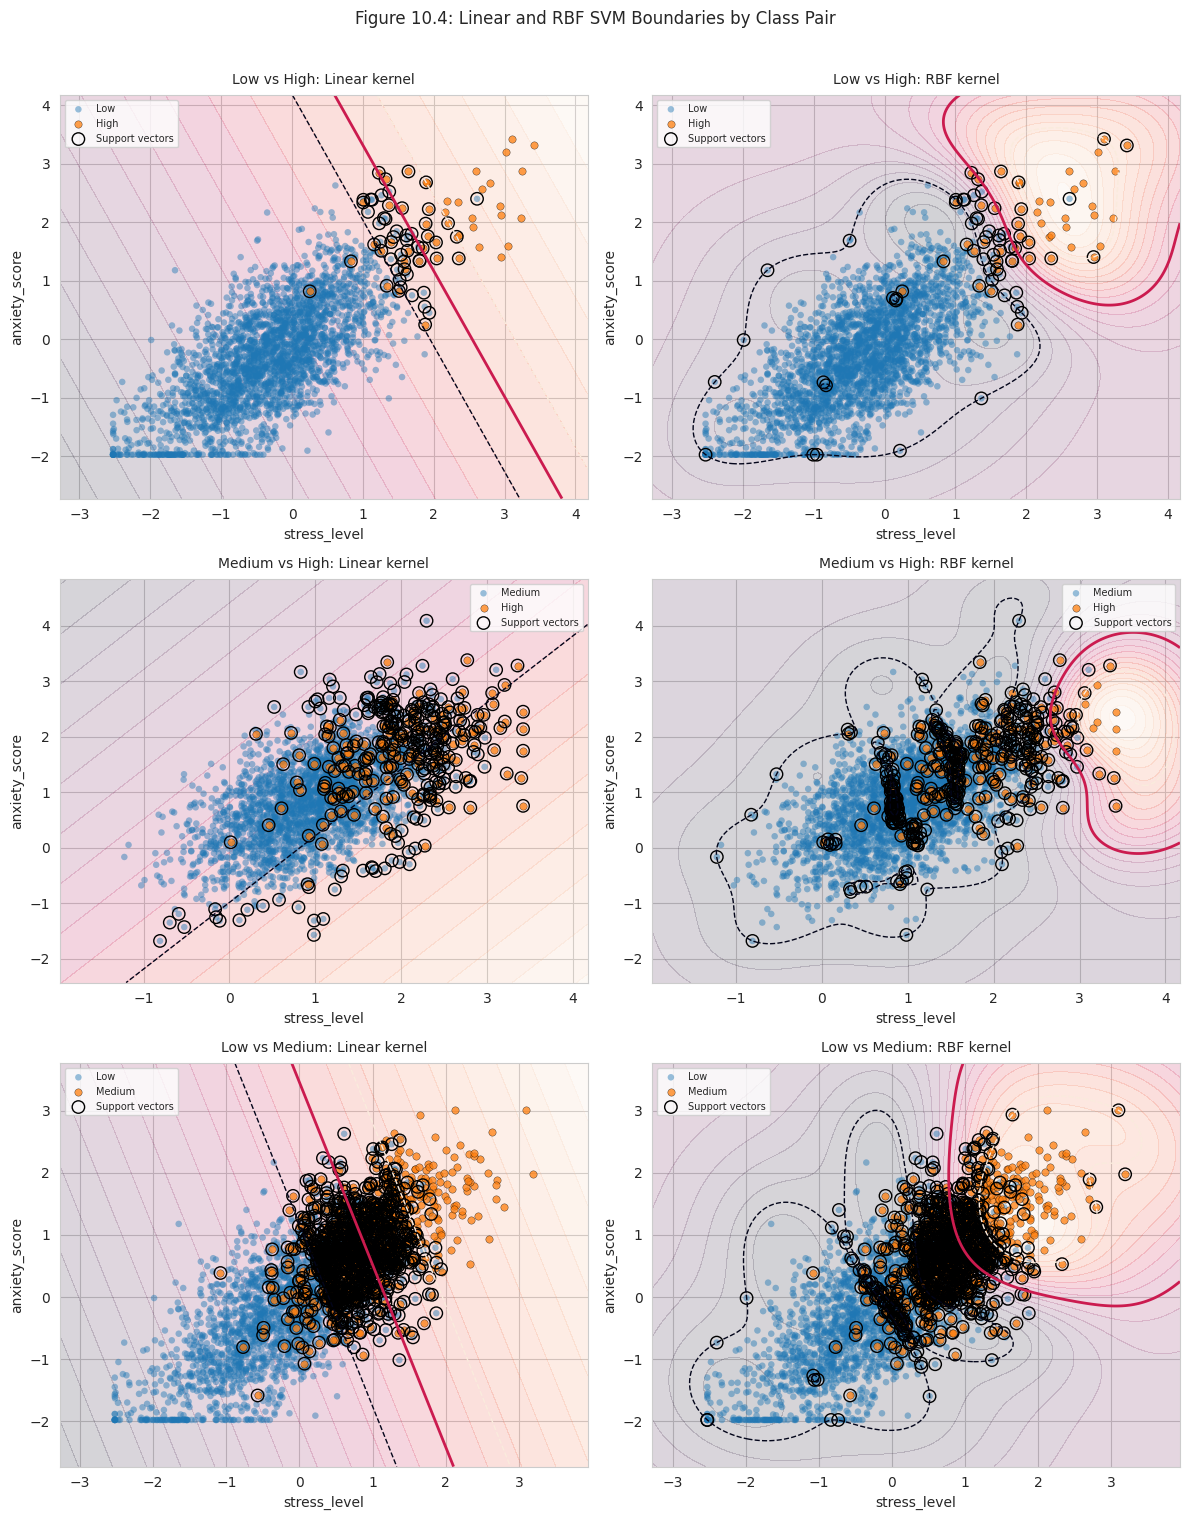

Saved: ../figures/ch10/fig10_4_pairwise_linear_rbf_boundaries.png


In [32]:
# Figure 10.4: Linear vs RBF SVM boundaries for all pairwise class comparisons

fig, axes = plt.subplots(len(pairwise_comparisons), 2, figsize=(12, 5 * len(pairwise_comparisons)))

if len(pairwise_comparisons) == 1:
    axes = np.array([axes])

for row_idx, (class_a, class_b, pair_label) in enumerate(pairwise_comparisons):
    X_pair, y_pair, _, _ = pairwise_visual_data[pair_label]

    linear_model = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)
    rbf_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)

    linear_model.fit(X_pair, y_pair)
    rbf_model.fit(X_pair, y_pair)

    plot_svm_decision_boundary(
        linear_model,
        X_pair,
        y_pair,
        title=f"{pair_label}: Linear kernel",
        ax=axes[row_idx, 0],
        class_labels=(class_name_map[class_a], class_name_map[class_b])
    )

    plot_svm_decision_boundary(
        rbf_model,
        X_pair,
        y_pair,
        title=f"{pair_label}: RBF kernel",
        ax=axes[row_idx, 1],
        class_labels=(class_name_map[class_a], class_name_map[class_b])
    )

fig.suptitle("Figure 10.4: Linear and RBF SVM Boundaries by Class Pair", fontsize=12, y=1.01)
plt.tight_layout()

fig_path_104 = os.path.join(FIGURES_DIR, "fig10_4_pairwise_linear_rbf_boundaries.png")
plt.savefig(fig_path_104, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_104}")

### Interpretation Note for Figure 10.4

Figure 10.4 makes the SVM concepts visible: the solid line is the decision boundary, the dashed lines show the margin, and the circled observations are support vectors. The linear kernel creates a straight boundary, while the RBF kernel allows a curved boundary. These plots are visual explanations only; they do not replace the full 19-feature test results.

## §7. Findings

In [33]:
results_df = pd.DataFrame([
    {
        'Method': 'Logistic Regression',
        'Kernel': 'N/A',
        'Best C': 'N/A',
        'Best Gamma': 'N/A',
        'Accuracy': round(log_accuracy, 4),
        'High-risk F1': round(log_high_f1, 4),
        'AUC-ROC': round(log_auc, 4),
    },
    {
        'Method': 'Linear SVM',
        'Kernel': 'linear',
        'Best C': best_c_linear,
        'Best Gamma': 'N/A',
        'Accuracy': round(linear_accuracy, 4),
        'High-risk F1': round(linear_high_f1, 4),
        'AUC-ROC': round(linear_auc, 4),
    },
    {
        'Method': 'RBF SVM',
        'Kernel': 'rbf',
        'Best C': best_c_rbf,
        'Best Gamma': best_gamma_rbf,
        'Accuracy': round(rbf_accuracy, 4),
        'High-risk F1': round(rbf_high_f1, 4),
        'AUC-ROC': round(rbf_auc, 4),
    },
])

svm_results_path = os.path.join(RESULTS_DIR, 'svm_results.csv')
results_df.to_csv(svm_results_path, index=False)

display(results_df)
print(f'Saved: {svm_results_path}')

,Method,Kernel,Best C,Best Gamma,Accuracy,High-risk F1,AUC-ROC
0,Logistic Regression,N/A,N/A,N/A,0.9873,0.4258,0.9827
1,Linear SVM,linear,0.01,N/A,0.9853,0.0639,0.9818
2,RBF SVM,rbf,0.1,0.01,0.9849,0.0000,0.9748


Saved: ../results/ch10/svm_results.csv


The findings table compares logistic regression, the linear SVM, and the RBF SVM on the same full test set. Accuracy shows the share of students classified correctly, High-risk F1 focuses on the rare High-risk class, and AUC-ROC measures how well the model separates High-risk students from the rest across possible thresholds. The RBF SVM should only replace logistic regression if its gain is large enough to justify losing coefficient-level explanations.

## §8. Real-World Decision

If the RBF SVM improves AUC-ROC or High-risk F1 only slightly over logistic regression, it should not replace the Chapter 5 logistic model in a student support setting. Logistic regression is easier to explain because it gives coefficients and odds ratios that advisors can connect back to stress, anxiety, sleep, and social support. An RBF SVM may be useful as a secondary benchmark, but it should only become the main screening model if it produces a clear gain in identifying High-risk students on the full test set. Without a substantial improvement, the more defensible decision is to keep the interpretable logistic regression model for advising and policy communication.

## §9. Caveats and Limitations

The SVM models are trained on a stratified 15,000-row subsample instead of the full 140,000-row training set, so the selected hyperparameters may vary if a different subsample is drawn. Standard SVM models do not provide native probability estimates unless probability calibration is enabled, so this chapter uses decision scores for AUC-ROC rather than calibrated risk probabilities. Kernel choice also requires judgment: the radial basis function kernel is flexible, but it does not explain which variables drove a specific prediction in the way logistic regression coefficients do.

## Appendix C: Additional Chapter 10 SVM Visualizations

The following plots support the SVM explanation but should be placed in Appendix C rather than the main Chapter 10 section. They are labeled as Appendix Figures so they do not interrupt the main chapter figure numbering.

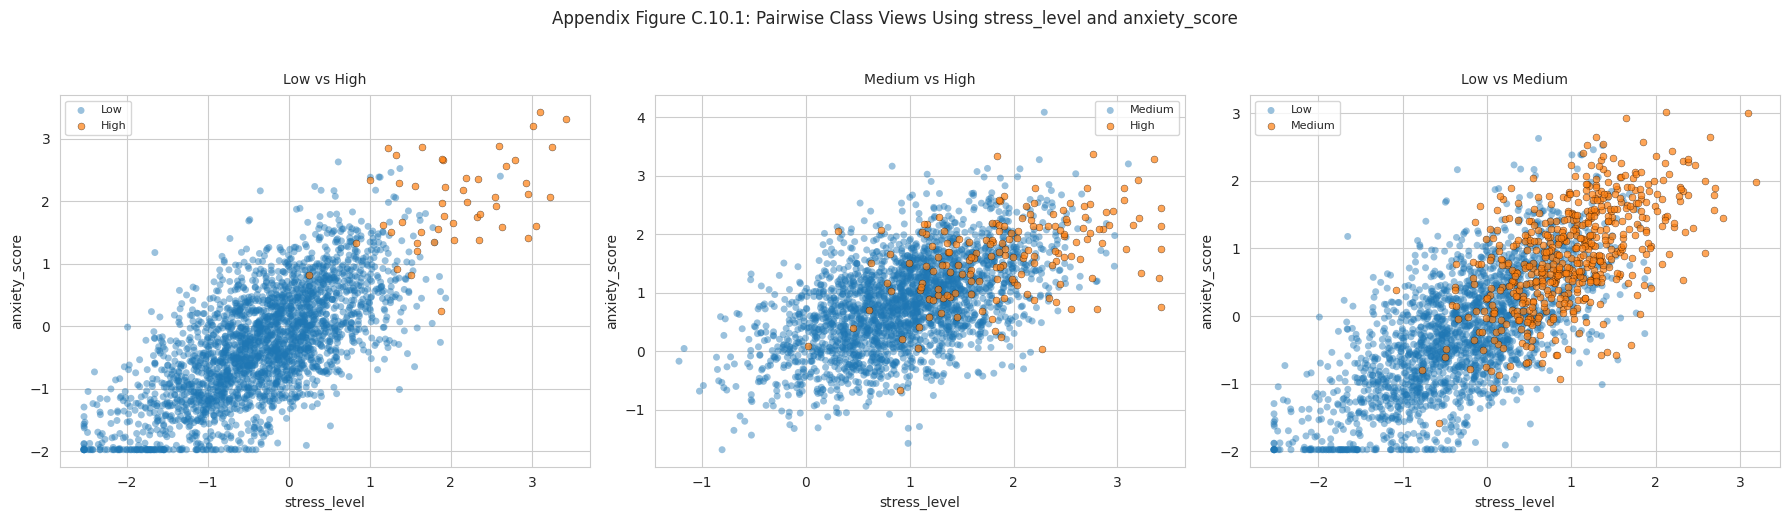

Saved: ../figures/ch10/appendix_c10_1_pairwise_class_scatter.png


In [34]:
# Appendix Figure C.10.1: Pairwise scatter plots for the two visual features

fig, axes = plt.subplots(1, len(pairwise_comparisons), figsize=(6 * len(pairwise_comparisons), 5))

if len(pairwise_comparisons) == 1:
    axes = [axes]

for ax, (class_a, class_b, pair_label) in zip(axes, pairwise_comparisons):
    X_pair, y_pair, _, _ = pairwise_visual_data[pair_label]

    ax.scatter(
        X_pair[y_pair == 0, 0],
        X_pair[y_pair == 0, 1],
        s=25,
        alpha=0.45,
        edgecolors="none",
        label=class_name_map[class_a]
    )

    ax.scatter(
        X_pair[y_pair == 1, 0],
        X_pair[y_pair == 1, 1],
        s=25,
        alpha=0.70,
        edgecolors="black",
        linewidths=0.3,
        label=class_name_map[class_b]
    )

    ax.set_xlabel("stress_level")
    ax.set_ylabel("anxiety_score")
    ax.set_title(pair_label, fontsize=10, pad=8)
    ax.legend(fontsize=8)

fig.suptitle("Appendix Figure C.10.1: Pairwise Class Views Using stress_level and anxiety_score", fontsize=12, y=1.03)
plt.tight_layout()

fig_path_c101 = os.path.join(FIGURES_DIR, "appendix_c10_1_pairwise_class_scatter.png")
plt.savefig(fig_path_c101, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_c101}")

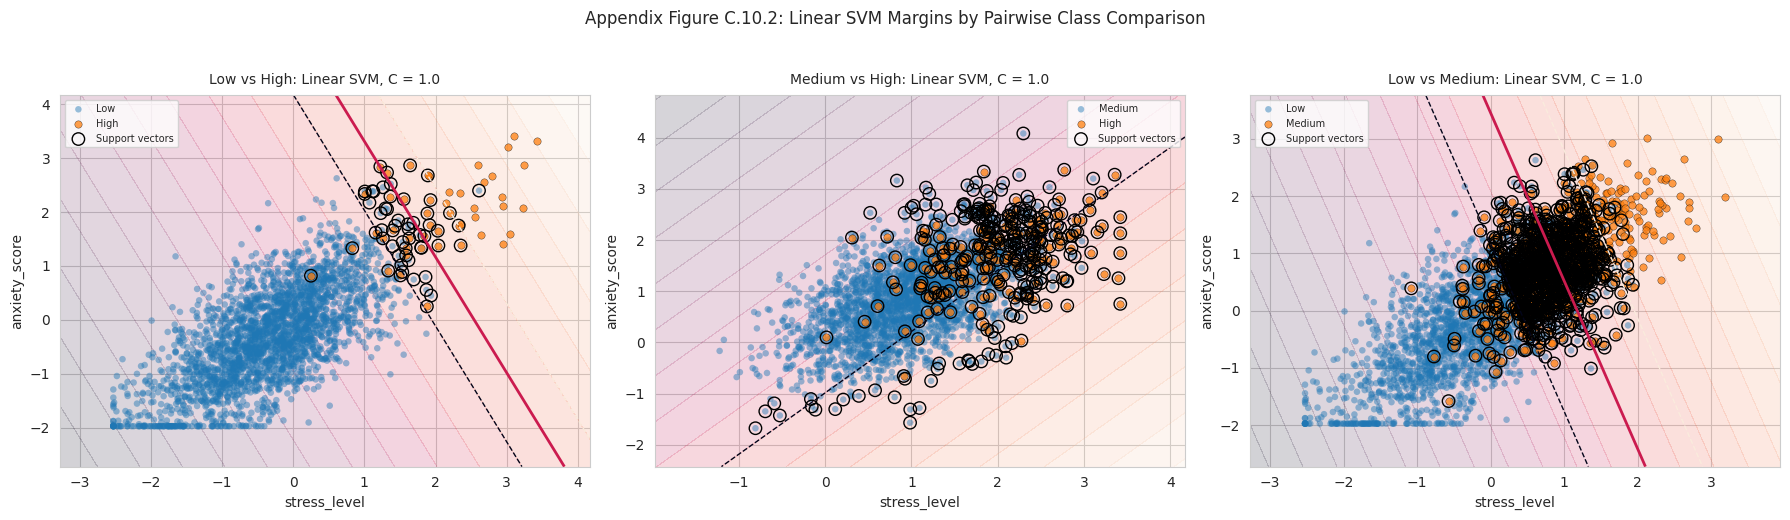

Saved: ../figures/ch10/appendix_c10_2_pairwise_linear_svm_margins.png


In [35]:
# Appendix Figure C.10.2: Linear SVM margins for each pairwise class comparison

fig, axes = plt.subplots(1, len(pairwise_comparisons), figsize=(6 * len(pairwise_comparisons), 5))

if len(pairwise_comparisons) == 1:
    axes = [axes]

pairwise_linear_models = {}

for ax, (class_a, class_b, pair_label) in zip(axes, pairwise_comparisons):
    X_pair, y_pair, _, _ = pairwise_visual_data[pair_label]

    model = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)
    model.fit(X_pair, y_pair)
    pairwise_linear_models[pair_label] = model

    plot_svm_decision_boundary(
        model,
        X_pair,
        y_pair,
        title=f"{pair_label}: Linear SVM, C = 1.0",
        ax=ax,
        class_labels=(class_name_map[class_a], class_name_map[class_b])
    )

fig.suptitle("Appendix Figure C.10.2: Linear SVM Margins by Pairwise Class Comparison", fontsize=12, y=1.03)
plt.tight_layout()

fig_path_c102 = os.path.join(FIGURES_DIR, "appendix_c10_2_pairwise_linear_svm_margins.png")
plt.savefig(fig_path_c102, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_c102}")

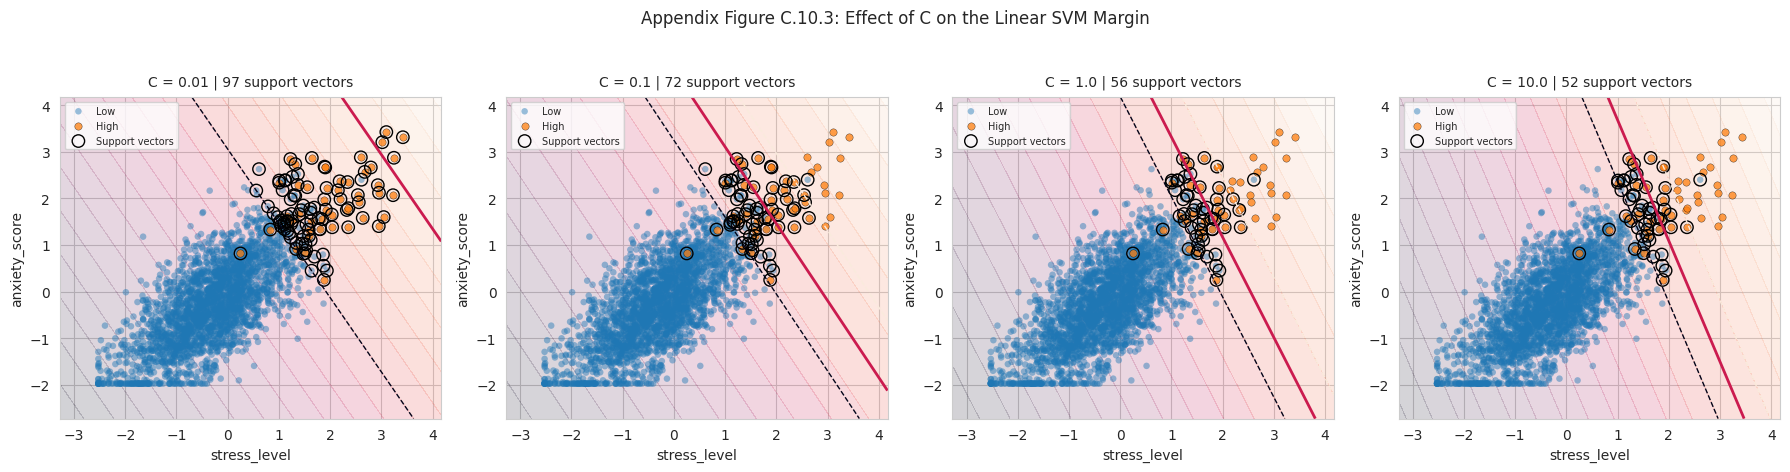

Saved: ../figures/ch10/appendix_c10_3_linear_svm_c_comparison.png


In [36]:
# Appendix Figure C.10.3: C parameter comparison for the Low vs High visual model
# This mirrors the lab notebook plot showing how C changes the margin.

target_pair_label = "Low vs High" if "Low vs High" in pairwise_visual_data else list(pairwise_visual_data.keys())[0]
X_pair, y_pair, class_a, class_b = pairwise_visual_data[target_pair_label]

C_values = [0.01, 0.1, 1.0, 10.0]

fig, axes = plt.subplots(1, len(C_values), figsize=(18, 4.5))

for ax, C_value in zip(axes, C_values):
    model = SVC(kernel="linear", C=C_value, random_state=RANDOM_STATE)
    model.fit(X_pair, y_pair)

    plot_svm_decision_boundary(
        model,
        X_pair,
        y_pair,
        title=f"C = {C_value} | {len(model.support_)} support vectors",
        ax=ax,
        class_labels=(class_name_map[class_a], class_name_map[class_b])
    )

fig.suptitle("Appendix Figure C.10.3: Effect of C on the Linear SVM Margin", fontsize=12, y=1.04)
plt.tight_layout()

fig_path_c103 = os.path.join(FIGURES_DIR, "appendix_c10_3_linear_svm_c_comparison.png")
plt.savefig(fig_path_c103, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_c103}")

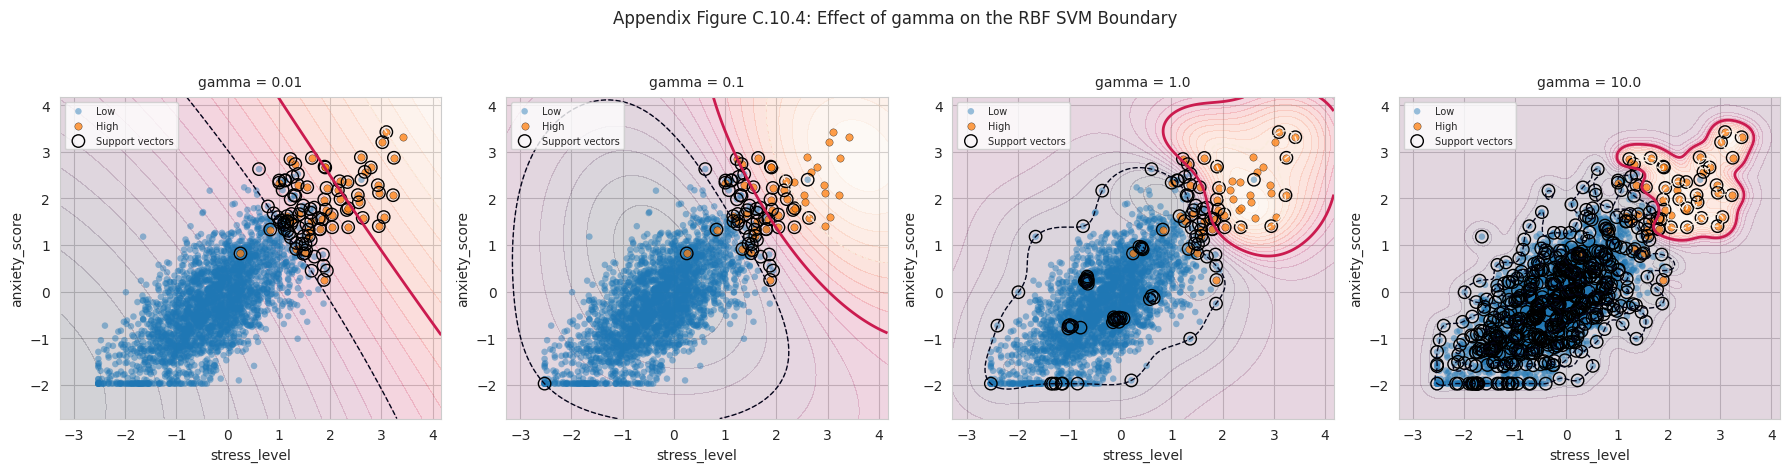

Saved: ../figures/ch10/appendix_c10_4_rbf_svm_gamma_comparison.png


In [37]:
# Appendix Figure C.10.4: Gamma comparison for the Low vs High RBF visual model
# This mirrors the lab notebook plot showing smooth versus wiggly boundaries.

target_pair_label = "Low vs High" if "Low vs High" in pairwise_visual_data else list(pairwise_visual_data.keys())[0]
X_pair, y_pair, class_a, class_b = pairwise_visual_data[target_pair_label]

gamma_values = [0.01, 0.1, 1.0, 10.0]

fig, axes = plt.subplots(1, len(gamma_values), figsize=(18, 4.5))

for ax, gamma_value in zip(axes, gamma_values):
    model = SVC(kernel="rbf", C=1.0, gamma=gamma_value, random_state=RANDOM_STATE)
    model.fit(X_pair, y_pair)

    plot_svm_decision_boundary(
        model,
        X_pair,
        y_pair,
        title=f"gamma = {gamma_value}",
        ax=ax,
        class_labels=(class_name_map[class_a], class_name_map[class_b])
    )

fig.suptitle("Appendix Figure C.10.4: Effect of gamma on the RBF SVM Boundary", fontsize=12, y=1.04)
plt.tight_layout()

fig_path_c104 = os.path.join(FIGURES_DIR, "appendix_c10_4_rbf_svm_gamma_comparison.png")
plt.savefig(fig_path_c104, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_c104}")

### Appendix Interpretation Note

Appendix Figures C.10.1 through C.10.4 show the same concepts used in the SVM lab walkthrough. A smaller C allows a wider margin with more support vectors, while a larger C creates a stricter boundary. For the RBF kernel, a small gamma gives a smoother boundary, while a large gamma creates a more flexible boundary that can overfit.

In [38]:
print('Chapter 10 complete. Files written:')
print()

print('Main chapter figures')
for p in [
    fig_path_101,
    fig_path_102,
    fig_path_103,
    fig_path_104
]:
    print(f' {p}')

print()

print('Appendix C figures')
for p in [
    fig_path_c101,
    fig_path_c102,
    fig_path_c103,
    fig_path_c104
]:
    print(f' {p}')

print()

print('Results')
for p in [svm_results_path, linear_cv_path, rbf_cv_path]:
    print(f' {p}')


Chapter 10 complete. Files written:

Main chapter figures
 ../figures/ch10/linear_svm_confusion.png
 ../figures/ch10/rbf_svm_confusion.png
 ../figures/ch10/roc_comparison.png
 ../figures/ch10/fig10_4_pairwise_linear_rbf_boundaries.png

Appendix C figures
 ../figures/ch10/appendix_c10_1_pairwise_class_scatter.png
 ../figures/ch10/appendix_c10_2_pairwise_linear_svm_margins.png
 ../figures/ch10/appendix_c10_3_linear_svm_c_comparison.png
 ../figures/ch10/appendix_c10_4_rbf_svm_gamma_comparison.png

Results
 ../results/ch10/svm_results.csv
 ../results/ch10/linear_svm_cv_results.csv
 ../results/ch10/rbf_svm_cv_results.csv
